# Sales Forecasting using Machine Learning

## Project Overview

This project builds a Machine Learning model to forecast future sales using historical business data from the Superstore Sales dataset.

The project demonstrates the complete machine learning workflow, including data cleaning, feature engineering, exploratory data analysis, model training, model evaluation, and future sales forecasting.

The objective is to help businesses make informed decisions regarding inventory management, staffing, budgeting, and future planning through data-driven sales predictions.

## Technologies Used

- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

## Table of Contents

1. Import Required Libraries
2. Load the Dataset
3. Explore the Dataset
4. Data Cleaning and Preprocessing
5. Feature Engineering
6. Monthly Sales Analysis
7. Exploratory Data Analysis
8. Train-Test Split
9. Model Training
10. Model Prediction
11. Model Evaluation
12. Actual vs Predicted Sales
13. Future Sales Forecast
14. Forecast Results
15. Historical Sales and Future Forecast
16. Business Insights and Conclusion

In [2]:
print("Sales Forecasting Project Started")

Sales Forecasting Project Started


## 1. Import Required Libraries

The required Python libraries are imported for data manipulation, visualization, and machine learning.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")


Libraries imported successfully


## 2. Load the Dataset

The Superstore Sales dataset is loaded into a Pandas DataFrame. This dataset contains historical order information, including sales, profit, customer details, product categories, and order dates.

In [4]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 3. Explore the Dataset

The dataset is explored to understand its structure, identify available features, inspect data types, and check for missing values before preprocessing.

In [5]:
df.shape 


(9994, 21)

In [6]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

## 4. Data Cleaning and Preprocessing

The data is prepared for analysis by converting the Order Date column into a datetime format. This allows time-based operations such as extracting months and years.

In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   str           
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

## 5. Feature Engineering

New time-based features are created from the Order Date column. These features enable the machine learning model to recognize patterns over time and perform forecasting.

In [10]:
df["Year"] = df["Order Date"].dt.year

In [11]:
df["Month"] = df["Order Date"].dt.month

In [12]:
df["Month Name"] = df["Order Date"].dt.month_name()

In [13]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October


In [14]:
df["Month-Year"] = df["Order Date"].dt.to_period("M")

In [15]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Month-Year
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,2016-11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,2016-11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2016-06
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,2015-10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,2015-10


## 6. Monthly Sales Analysis

Sales values are aggregated by month to analyze long-term trends and prepare the data for time-series forecasting.

In [16]:
monthly_sales = df.groupby("Month-Year")["Sales"].sum()

monthly_sales.head()

Month-Year
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: Sales, dtype: float64

In [17]:
monthly_sales.shape

(48,)

## 7. Exploratory Data Analysis

The historical monthly sales trend is visualized to identify overall growth, fluctuations, and possible seasonal patterns.

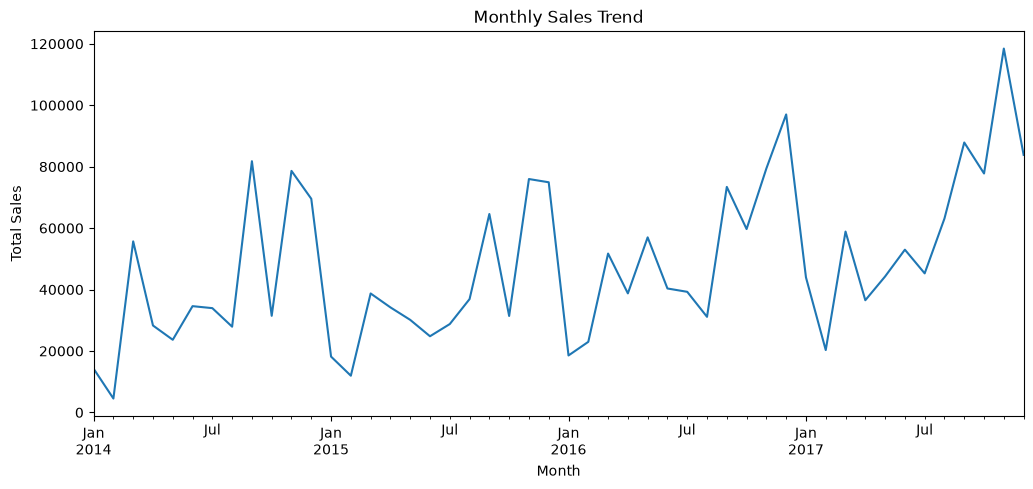

In [18]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.savefig("../images/historical_sales.png", bbox_inches="tight")

plt.show()

In [19]:
monthly_sales = monthly_sales.reset_index()

monthly_sales.head()

,Month-Year,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


In [20]:
monthly_sales["Time"] = range(1, len(monthly_sales) + 1)

monthly_sales.head()

,Month-Year,Sales,Time
0,2014-01,14236.895,1
1,2014-02,4519.892,2
2,2014-03,55691.009,3
3,2014-04,28295.345,4
4,2014-05,23648.287,5


In [21]:
monthly_sales.shape

(48, 3)

## 8. Train-Test Split

The monthly sales data is divided into training and testing sets. Earlier months are used for training, while the most recent months are reserved for evaluating the forecasting model.

In [22]:
train = monthly_sales[:-12]
test = monthly_sales[-12:]

print("Training data:", train.shape)
print("Testing data:", test.shape)

Training data: (36, 3)
Testing data: (12, 3)


In [23]:
X_train = train[["Time"]]
y_train = train["Sales"]

X_test = test[["Time"]]
y_test = test["Sales"]

## 9. Model Training

A Linear Regression model is trained using the Time feature to learn the relationship between time and monthly sales.

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
model = LinearRegression()

In [26]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[930.63]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Time']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.623e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## 10. Model Prediction

The trained model predicts sales for the testing dataset. These predictions will later be compared with the actual sales values.

In [27]:
predictions = model.predict(X_test)

predictions

array([60660.68181492, 61591.31085432, 62521.93989371, 63452.56893311,
       64383.1979725 , 65313.8270119 , 66244.45605129, 67175.08509069,
       68105.71413008, 69036.34316948, 69966.97220887, 70897.60124827])

In [28]:
results = test.copy()

results["Predicted Sales"] = predictions

results

,Month-Year,Sales,Time,Predicted Sales
36,2017-01,43971.3740,37,60660.681815
37,2017-02,20301.1334,38,61591.310854
38,2017-03,58872.3528,39,62521.939894
39,2017-04,36521.5361,40,63452.568933
40,2017-05,44261.1102,41,64383.197973
41,2017-06,52981.7257,42,65313.827012
42,2017-07,45264.4160,43,66244.456051
43,2017-08,63120.8880,44,67175.085091
44,2017-09,87866.6520,45,68105.714130
45,2017-10,77776.9232,46,69036.343169


## 11. Model Evaluation

Model performance is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). These metrics measure how closely the predictions match the actual sales values.

In [29]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Mean Absolute Error (MAE): 19663.55
Root Mean Squared Error (RMSE): 23664.5


## 12. Actual vs Predicted Sales

A comparison between the actual monthly sales and the predicted sales helps visualize how well the model captures the historical trend.

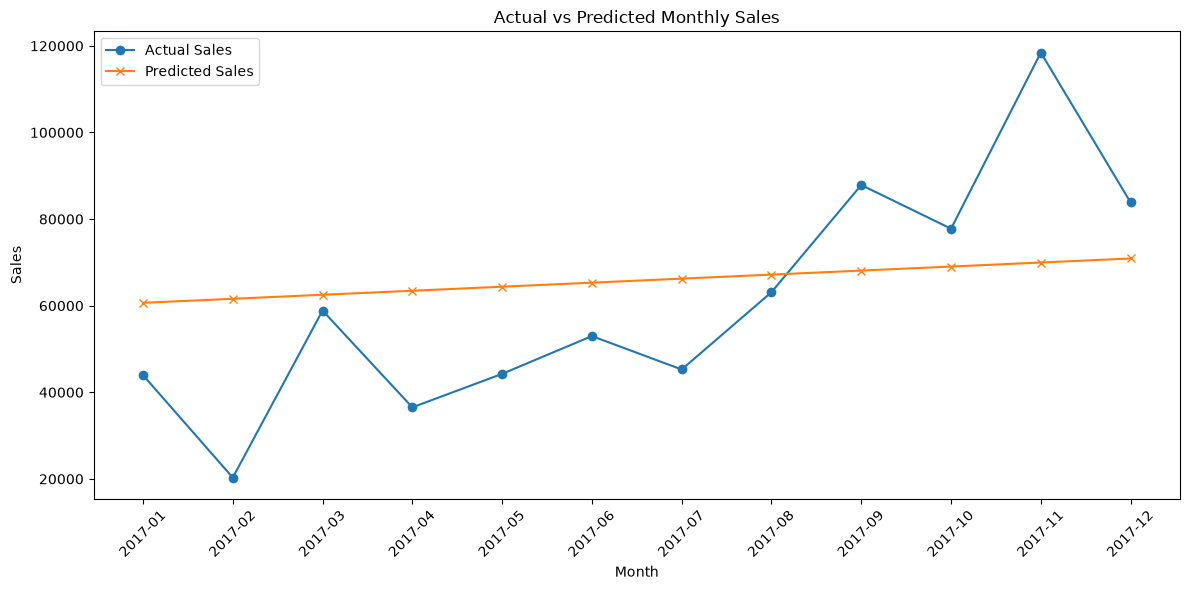

In [38]:
plt.figure(figsize=(12,6))

plt.plot(test["Month-Year"].astype(str), y_test, label="Actual Sales", marker="o")
plt.plot(test["Month-Year"].astype(str), predictions, label="Predicted Sales", marker="x")

plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.savefig("../images/actual_vs_predicted.png", bbox_inches="tight")

plt.show()

## 13. Future Sales Forecast

The trained model is used to forecast sales for the next twelve months beyond the available historical data.

In [31]:
import pandas as pd

future_time = pd.DataFrame({
    "Time": range(monthly_sales["Time"].max() + 1,
                  monthly_sales["Time"].max() + 13)
})

future_time

,Time
0,49
1,50
2,51
3,52
4,53
5,54
6,55
7,56
8,57
9,58


In [32]:
future_predictions = model.predict(future_time)

future_predictions

array([71828.23028766, 72758.85932706, 73689.48836645, 74620.11740585,
       75550.74644524, 76481.37548464, 77412.00452403, 78342.63356343,
       79273.26260282, 80203.89164222, 81134.52068161, 82065.14972101])

In [33]:
last_month = monthly_sales["Month-Year"].iloc[-1].to_timestamp()

future_months = pd.date_range(
    start=last_month + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

future_months

DatetimeIndex(['2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01',
               '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01',
               '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01'],
              dtype='datetime64[us]', freq='MS')

## 14. Forecast Results

The forecasted monthly sales values are presented in a structured table for easier interpretation and business planning.

In [34]:
future_forecast = pd.DataFrame({
    "Month": future_months.strftime("%Y-%m"),
    "Forecasted Sales": future_predictions
})

future_forecast

,Month,Forecasted Sales
0,2018-01,71828.230288
1,2018-02,72758.859327
2,2018-03,73689.488366
3,2018-04,74620.117406
4,2018-05,75550.746445
5,2018-06,76481.375485
6,2018-07,77412.004524
7,2018-08,78342.633563
8,2018-09,79273.262603
9,2018-10,80203.891642


## 15. Historical Sales and Future Forecast

The final visualization combines historical sales with forecasted sales, providing a business-friendly view of expected future performance.

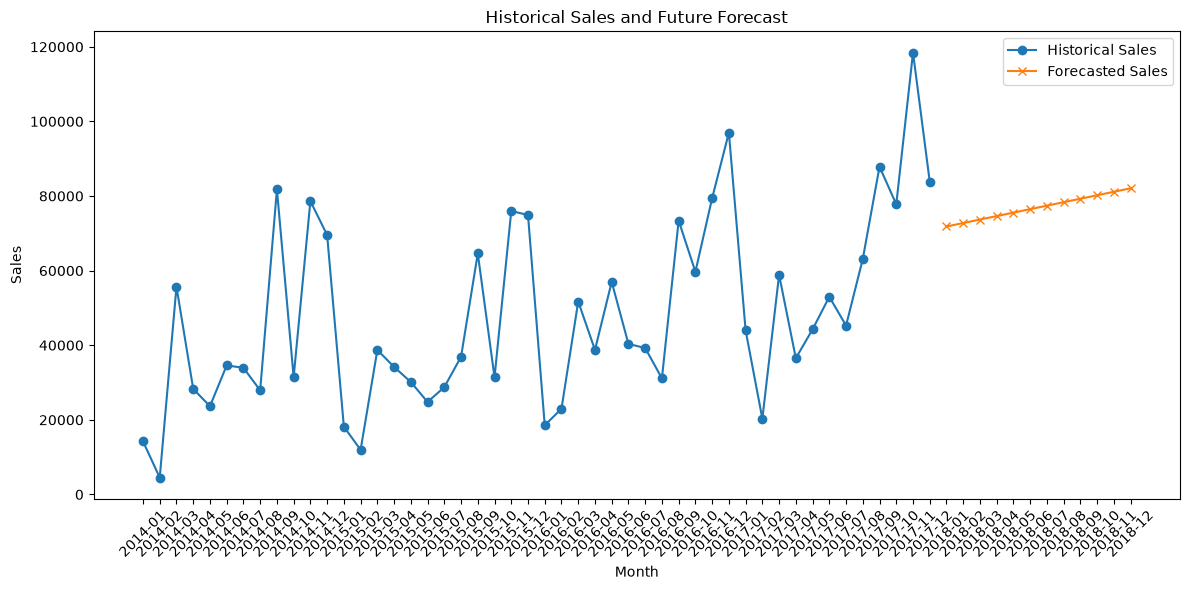

In [37]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Month-Year"].astype(str),
    monthly_sales["Sales"],
    label="Historical Sales",
    marker="o"
)

plt.plot(
    future_forecast["Month"],
    future_forecast["Forecasted Sales"],
    label="Forecasted Sales",
    marker="x"
)

plt.title("Historical Sales and Future Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()

plt.savefig("../images/future_forecast.png", bbox_inches="tight")

plt.show()

# Business Insights and Conclusion

## Key Findings

- Historical sales showed noticeable fluctuations over time with several significant peaks and declines.
- Linear Regression successfully captured the overall sales trend but was less effective at predicting sudden spikes and seasonal variations.
- The forecasting model generated sales estimates for the next twelve months, providing a simple baseline forecast for future planning.

## Business Value

Businesses can use these forecasts to:

- Improve inventory planning
- Estimate future revenue
- Support budgeting and financial planning
- Schedule staffing based on expected demand
- Reduce the risk of overstocking or stock shortages

## Limitations

The Linear Regression model uses only the Time feature and therefore cannot fully capture complex seasonal patterns or sudden changes in demand.

More advanced forecasting techniques such as ARIMA, Facebook Prophet, or XGBoost could improve forecasting accuracy.

## Conclusion

This project demonstrates a complete machine learning workflow for sales forecasting using historical business data. From data preparation and feature engineering to model evaluation and future forecasting, the project illustrates how machine learning can support business decision-making through data-driven insights.